# Koopman Operator Training with Autoencoder

This notebook implements a training pipeline for a Koopman operator model combined with an autoencoder. The code includes data loading, model definition, training, and visualization of results such as trajectories and eigenvalues.


In [1]:
import os
# Move up one directory to make sure the script can find the modules and save files in the correct place
os.chdir('..')
# Verify the current working directory
print(os.getcwd())

import argparse
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn.init as init
import torch.multiprocessing as mp

# Import local modules (assuming these are available in your environment)
from utils.tools import set_seed, get_device
from utils.config_args import get_args
from utils.Viz import *
from KoopmanTrainer_AFT_DR import Trainer
from data_handler import KoopmanDataHandler
from models.autoencoder import AutoEncoder
from models.efficient_kan import *
from models.koopman_operator import Knet
from models.AFT import AttentionFreeTransformer

# Set multiprocessing start method
try:
    mp.set_start_method('spawn')
except RuntimeError:
    pass  # method already set

# Disable deterministic algorithms for flexibility
torch.use_deterministic_algorithms(False)


/Users/mohammedahmed/Desktop/Project/KoopKAN/Clean Code/bio-koopman-autoencoder


## Training Settings

Configure the training settings, including random seeds for reproducibility and device selection (CUDA or CPU).

In [2]:
# the version of pandas
def get_pandas_version():
    import numpy as np
    import pandas as pd
    return pd.__version__
print(f"Pandas version: {get_pandas_version()}")
import numpy as np
print(f"NumPy version: {np.__version__}")

Pandas version: 2.2.2
NumPy version: 2.0.1


In [3]:
# Get arguments (assuming get_args() handles command-line or default args)
args = get_args()

# Set seeds for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.cuda.manual_seed(args.seed)
torch.manual_seed(args.seed)
np.random.seed(args.seed)
set_seed(args.seed)

# Device configuration
device = get_device()

Using the CPU


In [4]:
# editing the args 
# in this experiement we increased the timesteps to 201 and the time to 40 which is double the original experiment to make sure we would capture the limit cycle 
args.dataset = 'pendulum'
args.folder = 'pendulum_AFT_DR'
args.time_steps = 201
args.prediction_length = 40
args.max_time = 10
args.num_samples = 6000
args.bottleneck = 100
args.decoder_loss_weight = .1
args.lr = 1e-3
args.epochs = 100
args.loss_function = 'mse'
args.unitary_loss_weight = 10
args.context_length = 10
args.load_from_checkpoint = False
#args.batch_size = 512


## Create Experiment Folder

Set up the folder structure to save experiment results, including arguments in a JSON file.

In [5]:
# Create experiment folder
experiment_folder = 'experiments'
if not os.path.isdir(experiment_folder):
    os.mkdir(experiment_folder)

folder_path = os.path.join(experiment_folder, args.folder)
os.makedirs(folder_path, exist_ok=True)

# Save arguments to JSON
args_dict = vars(args)
with open(os.path.join(folder_path, 'args.json'), 'w') as f:
    json.dump(args_dict, f,indent=2)

## Load and Prepare Dataset

Load and preprocess the dataset using the `KoopmanDataHandler` class, then create data loaders for training, validation, and testing.

In [6]:
# Convert args to a dictionary for the data handler

config = {
    "dataset": args.dataset,
    "data_dir": args.data_dir,
    "train_size": args.train_size,
    "val_size": args.val_size,
    "batch_size": args.batch_size,
    "noise": args.noise,
    "orthogonal_projection": args.orthogonal_projection,
    "num_combinations": args.num_combinations,
    "num_samples": args.num_samples,
    "time_steps": args.time_steps,
    "max_time": args.max_time,
    "normalize": args.normalize,
    "prediction_length": args.prediction_length,
    "stride": args.stride,
    "device": device,
    "theta": args.theta
}

# Initialize data handler
data_handler = KoopmanDataHandler(config)
data_handler.load_data()
preprocessed_data = data_handler.preprocess()
dataloaders = data_handler.create_dataloaders()

train_loader = dataloaders["train"]
val_loader = dataloaders["val"]
test_loader = dataloaders["test"]

# Get data dimensions for model initialization
input_size = preprocessed_data['Xtrain'].shape[-1]

100%|██████████| 6000/6000 [00:00<00:00, 33066.42it/s]
/Users/mohammedahmed/Desktop/Project/KoopKAN/Clean Code/bio-koopman-autoencoder/data_handler.py:157: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xtrain = torch.tensor(Xtrain, dtype=torch.float32).to(self.device)
/Users/mohammedahmed/Desktop/Project/KoopKAN/Clean Code/bio-koopman-autoencoder/data_handler.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xval = torch.tensor(Xval, dtype=torch.float32).to(self.device)
/Users/mohammedahmed/Desktop/Project/KoopKAN/Clean Code/bio-koopman-autoencoder/data_handler.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor

the shape of the data is torch.Size([6000, 201, 2])
Processing dataset: pendulum
train_idx: 4800, val_idx: 5400
Processed data shapes - Train: torch.Size([4800, 201, 2]), Val: torch.Size([600, 201, 2]), Test: torch.Size([600, 201, 2])


## Model Definition

Define the autoencoder (`AutoEncoder`) and Koopman operator (`Knet`), then combine them into a `ModuleDict`.

In [7]:
# Model definition
ae = AutoEncoder(
    input_size=input_size,
    encoded_size=args.bottleneck,
    encoder_hidden_layers=args.encoder_hidden_layers,
    decoder_hidden_layers=args.decoder_hidden_layers,
    network_type=args.network_type,
    batch_norm=False
)
knet = Knet(size=args.bottleneck)

AFT = AttentionFreeTransformer(d_model=args.bottleneck, max_seq_len=args.context_length, device=device)

# Combine AE and Knet as a ModuleDict
model = torch.nn.ModuleDict({'ae': ae, 'knet': knet,'aft_layer': AFT})
model = model.to(device)

## Model Summary

Display the total number of parameters and the model architecture.

In [8]:
print('**** Setup ****')
print('Total params: %.2fM' % (sum(p.numel() for p in model.parameters())/1000000.0))
print('Total params: %.2fk' % (sum(p.numel() for p in model.parameters())/1000.0))
print('************')

print('**** Model Architecture ****')
print(model)
print('***************************')

**** Setup ****
Total params: 0.08M
Total params: 81.30k
************
**** Model Architecture ****
ModuleDict(
  (ae): AutoEncoder(
    (encoder): Sequential(
      (0): MLP(
        (net): ModuleList(
          (0): Linear(in_features=2, out_features=100, bias=True)
          (1): LeakyReLU(negative_slope=0.01)
          (2): Linear(in_features=100, out_features=100, bias=True)
          (3): LeakyReLU(negative_slope=0.01)
          (4): Linear(in_features=100, out_features=100, bias=True)
        )
      )
      (1): Dropout(p=0.3, inplace=False)
    )
    (decoder): MLP(
      (net): ModuleList(
        (0): Linear(in_features=100, out_features=100, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): Linear(in_features=100, out_features=100, bias=True)
        (3): LeakyReLU(negative_slope=0.01)
        (4): Linear(in_features=100, out_features=2, bias=True)
      )
    )
  )
  (knet): Knet(
    (net): Linear(in_features=100, out_features=100, bias=False)
  )
  (aft_

## Load from Checkpoint

Optionally load a pre-trained model from a checkpoint if specified.

In [9]:
if args.load_from_checkpoint:
    checkpoint_path = os.path.join(folder_path, 'model.pkl')
    if os.path.isfile(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path))
        print(f'Model loaded from {checkpoint_path}')
    else:
        print(f'No checkpoint found at {checkpoint_path}')


## Training

Train the model using the `Trainer` class with the specified data loaders.

In [10]:
trainer = Trainer(model, args, device, do_eval=True, train_loader=train_loader, val_loader=val_loader)

Using the CPU


In [11]:
trainer.train_KoopmanAE()

Training Epochs:   5%|▌         | 5/100 [05:40<1:46:56, 67.54s/it]

Epoch 5/100
Training - Recon Loss: 8.127973e-04, Linear Loss: 8.424498e-05, Pred Loss: 3.833588e-03, Unitary Loss: 9.329961e-05, Total Loss: 1.481880e-03
Validation - Recon Loss: 2.683469e-04, Linear Loss: 3.917777e-05, Pred Loss: 2.115145e-03,Unitary Loss: 6.081558e-05, Total Loss: 2.775270e-04


Training Epochs:  10%|█         | 10/100 [11:32<1:43:23, 68.93s/it]

Epoch 10/100
Training - Recon Loss: 6.735624e-04, Linear Loss: 6.461805e-05, Pred Loss: 2.379578e-03, Unitary Loss: 3.075896e-06, Total Loss: 4.006911e-04
Validation - Recon Loss: 1.279205e-04, Linear Loss: 2.494512e-05, Pred Loss: 1.980148e-03,Unitary Loss: 2.829835e-06, Total Loss: 2.357520e-04


Training Epochs:  15%|█▌        | 15/100 [17:16<1:38:49, 69.75s/it]

...

Training Epochs:  95%|█████████▌| 95/100 [1:48:47<05:56, 71.24s/it]

Epoch 95/100
Training - Recon Loss: 2.471832e-04, Linear Loss: 1.758306e-05, Pred Loss: 6.240366e-04, Unitary Loss: 1.477096e-06, Total Loss: 1.194760e-04
Validation - Recon Loss: 8.737378e-05, Linear Loss: 5.678148e-06, Pred Loss: 6.675802e-04,Unitary Loss: 1.692602e-06, Total Loss: 8.117355e-05


Training Epochs: 100%|██████████| 100/100 [1:54:25<00:00, 68.66s/it]

Epoch 100/100
Training - Recon Loss: 2.562711e-04, Linear Loss: 1.812190e-05, Pred Loss: 6.554262e-04, Unitary Loss: 1.824570e-06, Total Loss: 1.275373e-04
Validation - Recon Loss: 1.550011e-04, Linear Loss: 6.982507e-06, Pred Loss: 1.048796e-03,Unitary Loss: 2.690257e-06, Total Loss: 1.273622e-04


(ModuleDict(
   (ae): AutoEncoder(
     (encoder): Sequential(
       (0): MLP(
         (net): ModuleList(
           (0): Linear(in_features=2, out_features=100, bias=True)
           (1): LeakyReLU(negative_slope=0.01)
           (2): Linear(in_features=100, out_features=100, bias=True)
           (3): LeakyReLU(negative_slope=0.01)
           (4): Linear(in_features=100, out_features=100, bias=True)
         )
       )
       (1): Dropout(p=0.3, inplace=False)
     )
     (decoder): MLP(
       (net): ModuleList(
         (0): Linear(in_features=100, out_features=100, bias=True)
         (1): LeakyReLU(negative_slope=0.01)
         (2): Linear(in_features=100, out_features=100, bias=True)
         (3): LeakyReLU(negative_slope=0.01)
         (4): Linear(in_features=100, out_features=2, bias=True)
       )
     )
   )
   (knet): Knet(
     (net): Linear(in_features=100, out_features=100, bias=False)
   )
   (aft_layer): AttentionFreeTransformer(
     (Wq): Linear(in_features=100, ou

In [12]:
trainer.test_KoopmanAE(test_loader)

Test - Recon Loss: 1.564939e-04, Linear Loss: 7.150264e-06, Pred Loss: 9.970133e-04, Total Loss: 1.225010e-04


## Visualization

Visualize the original, reconstructed, and predicted trajectories from the test set.

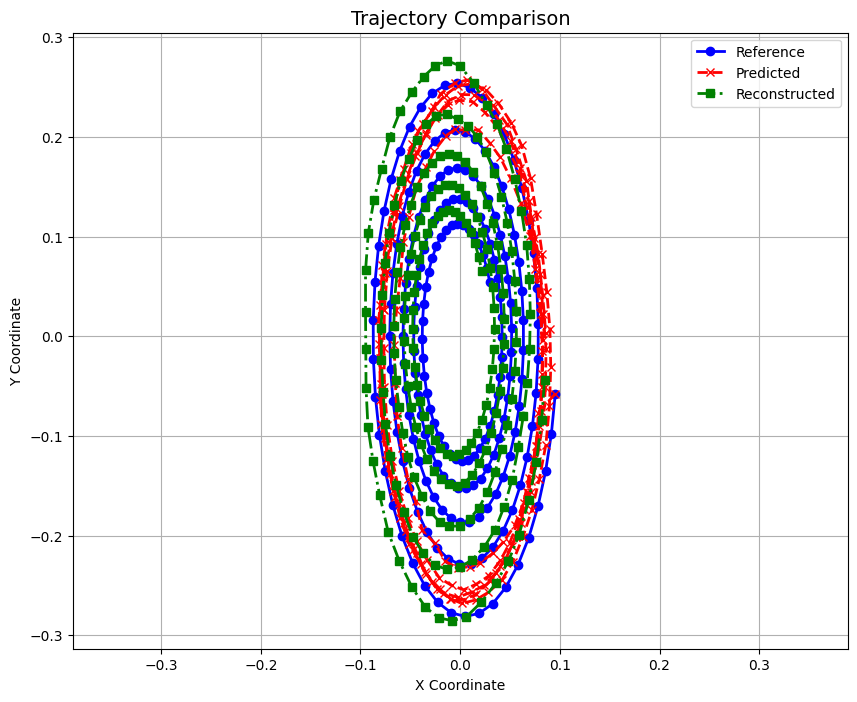

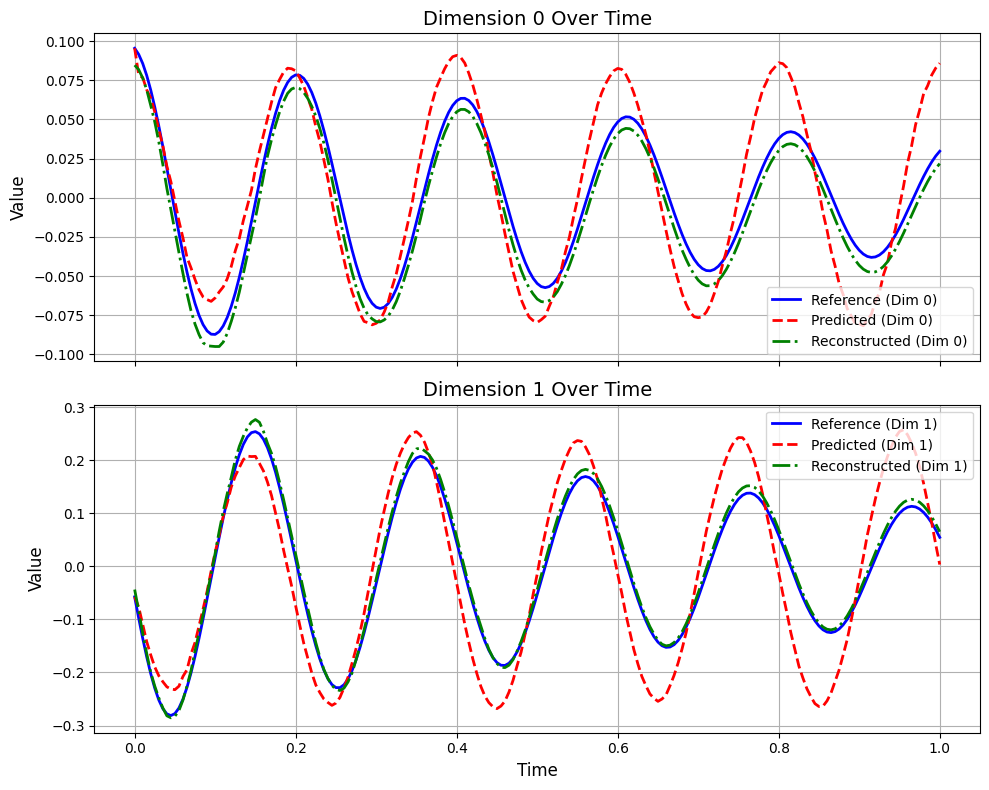

In [13]:
# for saving the results first

# Get a test sample
traj = preprocessed_data["Xtest"][7].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj, latent_prediction = trainer.predict_new(X0=traj[0], steps=len(traj)-1)

# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)

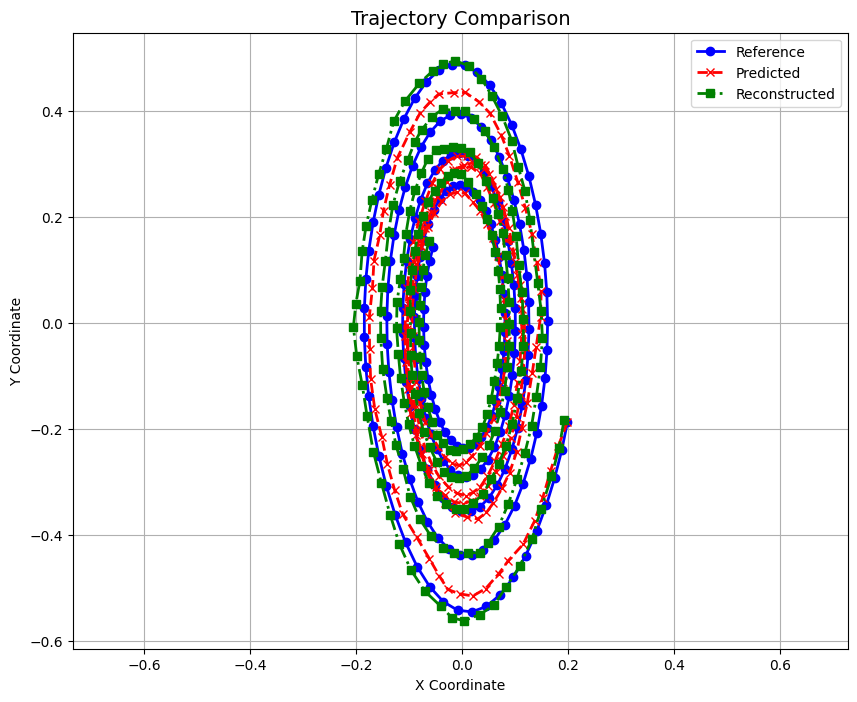

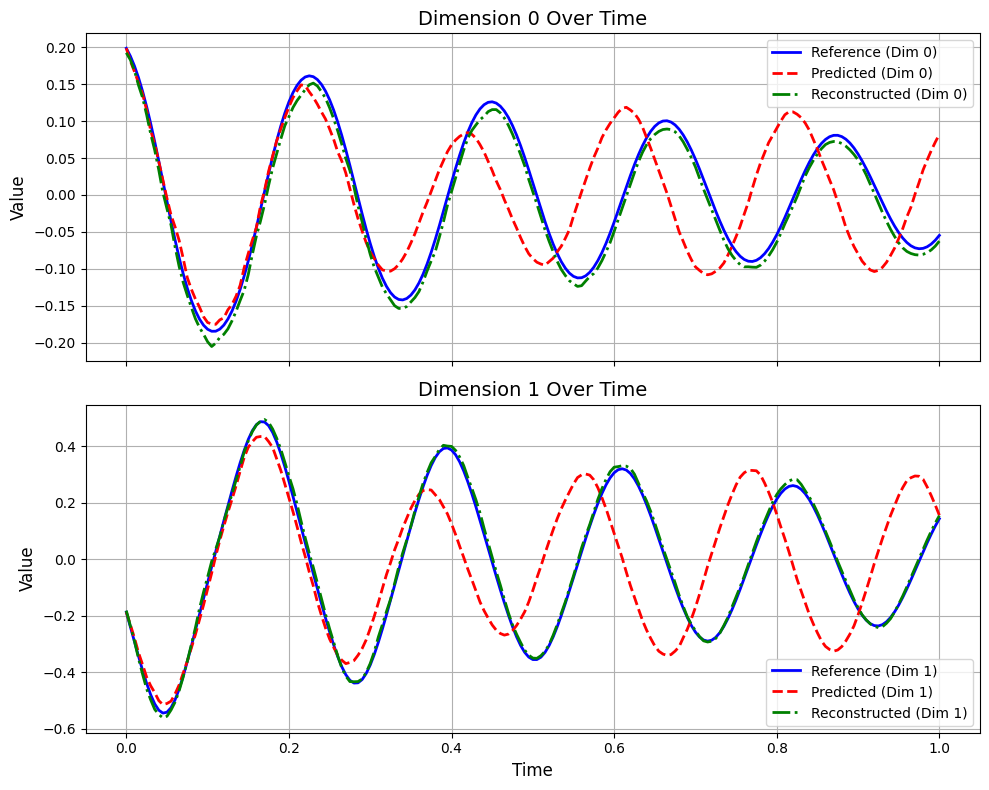

In [14]:
# for saving the results first

# Get a test sample
traj = preprocessed_data["Xtest"][9].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj, latent_prediction = trainer.predict_new(X0=traj[0], steps=len(traj)-1)

# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)

Reencoding points: [3, 4, 5, 6, 7, 25, 31, 32, 33, 34, 35, 36, 37, 38, 39, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 73, 79, 80, 81, 82, 83, 84, 85, 86, 87, 93, 94, 95, 96, 97, 98, 99, 105, 106, 107, 108, 109, 110, 111, 112, 118, 119, 120, 121, 122, 123, 124, 130, 131, 132, 133, 134, 135, 136, 137, 143, 144, 145, 146, 147, 148, 149, 155, 156, 157, 158, 159, 160, 161, 162, 168, 169, 170, 171, 172, 173, 174, 180, 181, 182, 183, 184, 185, 186, 187, 193, 194, 195, 196, 197, 198, 199]


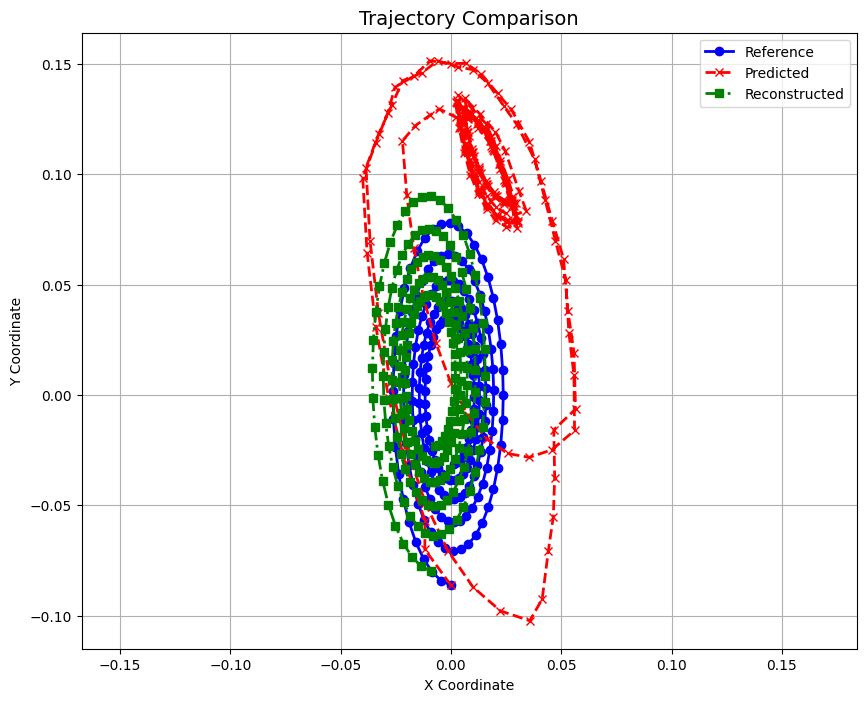

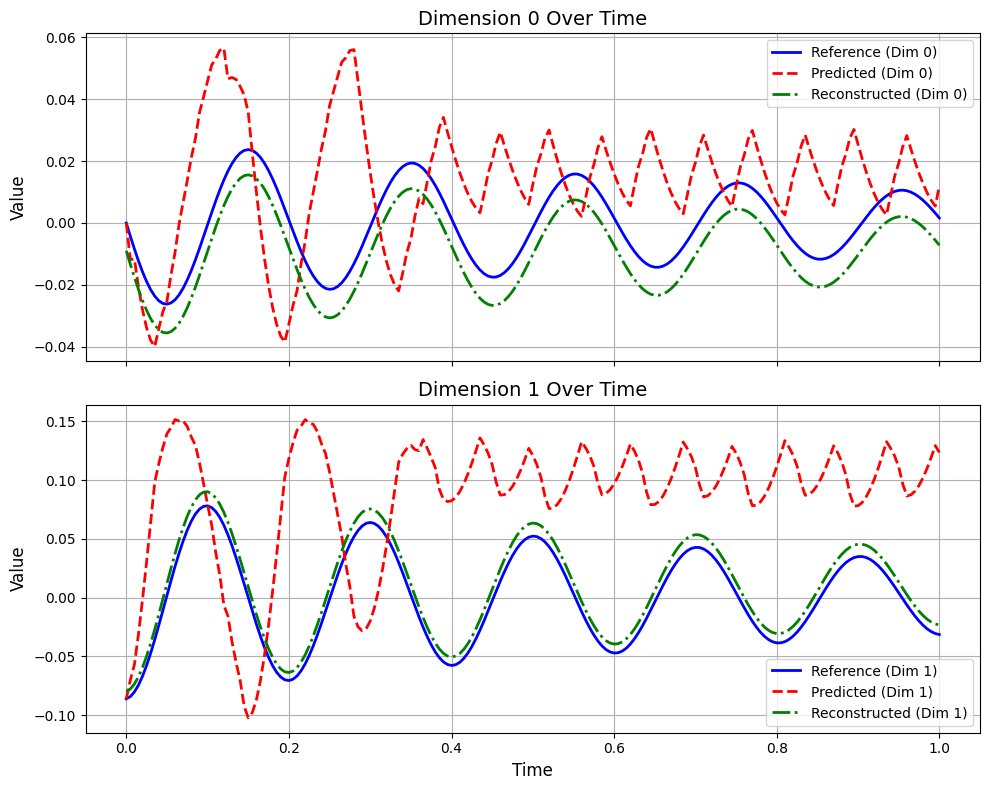

In [17]:
# for saving the results first

# Get a test sample
traj = preprocessed_data["Xtest"][0].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj, latent_prediction, reencoding_points = trainer.predict_with_threshold(X0=traj[0], steps=len(traj)-1, threshold=1)

print(f"Reencoding points: {reencoding_points}")

# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)

Reencoding points: [33, 71, 150, 151, 153, 189]


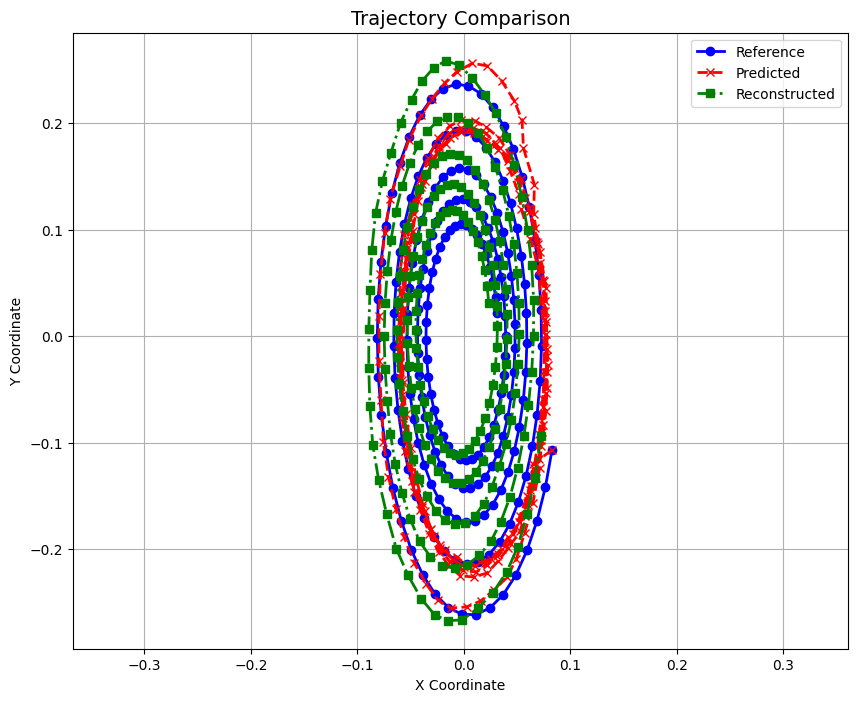

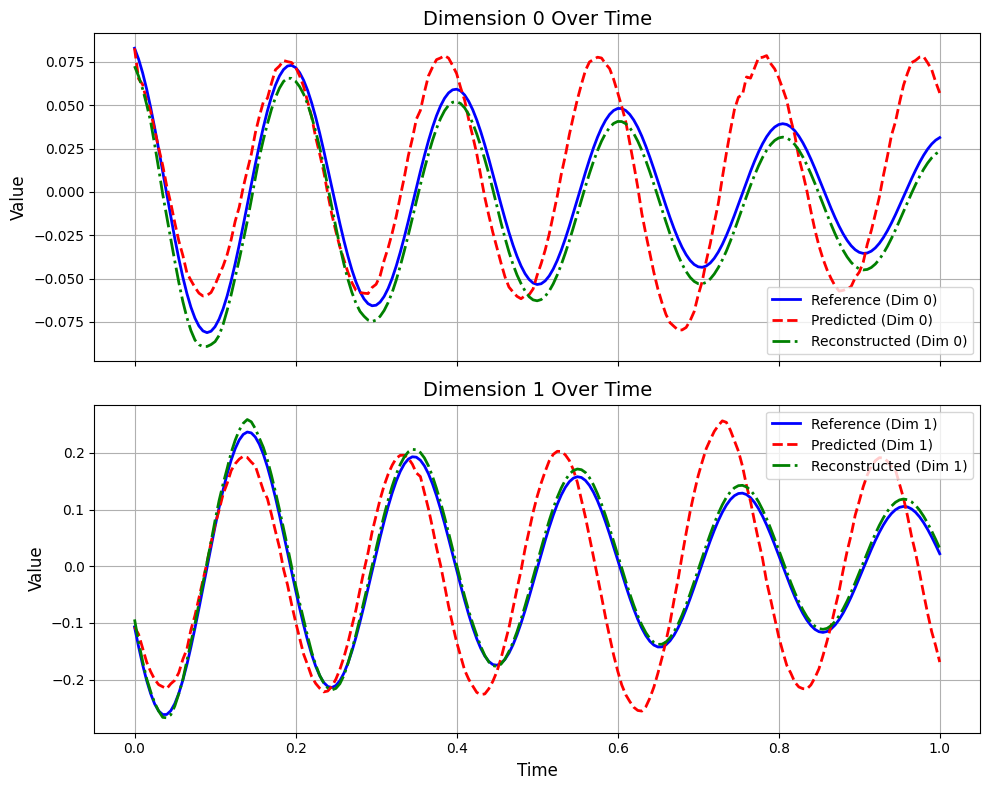

In [22]:
# for saving the results first

# Get a test sample
traj = preprocessed_data["Xtest"][3].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj, latent_prediction, reencoding_points, _ = trainer.predict_window_variance(X0=traj[0], steps=len(traj)-1, window_size=10, variance_threshold=2)


print(f"Reencoding points: {reencoding_points}")
# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)

## Long Term Prediction

## Long Term Prediction

In [35]:
from utils.data_loader import GoodwinOscillator

Y0 = np.random.uniform(-2, 2, 3)

goodwin_model = GoodwinOscillator(y0=Y0)

parameters = [360, 43, 1.0, 12, 0.6, 1.0, 1.0, 1.0, 0.8]

times = np.linspace(0, 200, 1001)

traj = goodwin_model.simulate(parameters, times)

traj = traj/data_handler.Xscale


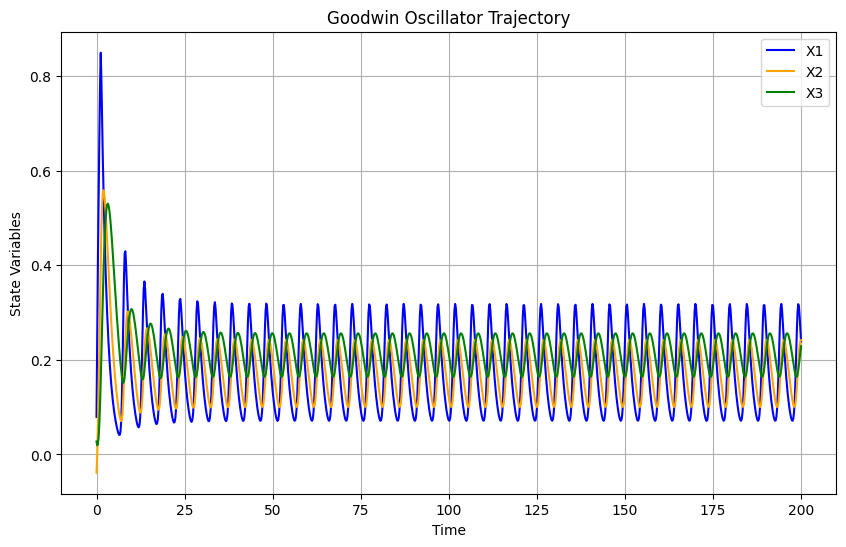

In [36]:
# visualize the trajectory

plt.figure(figsize=(10, 6))
plt.plot(times, traj[:, 0], label='X1', color='blue')
plt.plot(times, traj[:, 1], label='X2', color='orange')
plt.plot(times, traj[:, 2], label='X3', color='green')
plt.title('Goodwin Oscillator Trajectory')
plt.xlabel('Time')
plt.ylabel('State Variables')
plt.legend()
plt.grid()

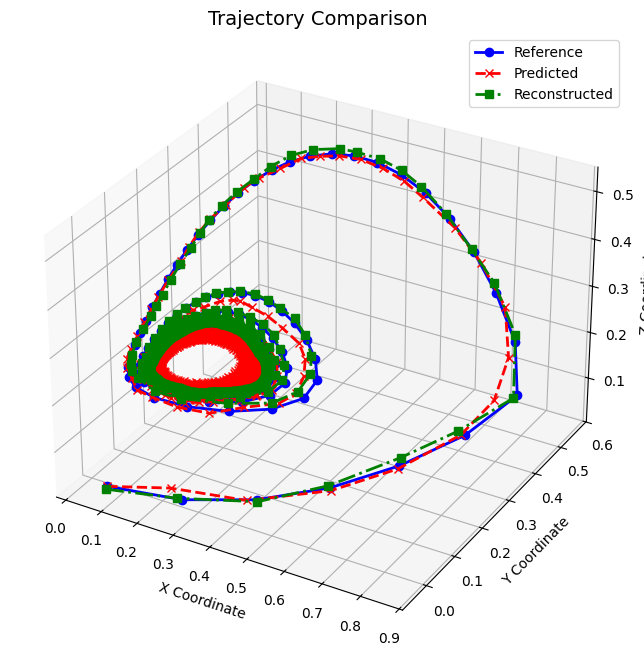

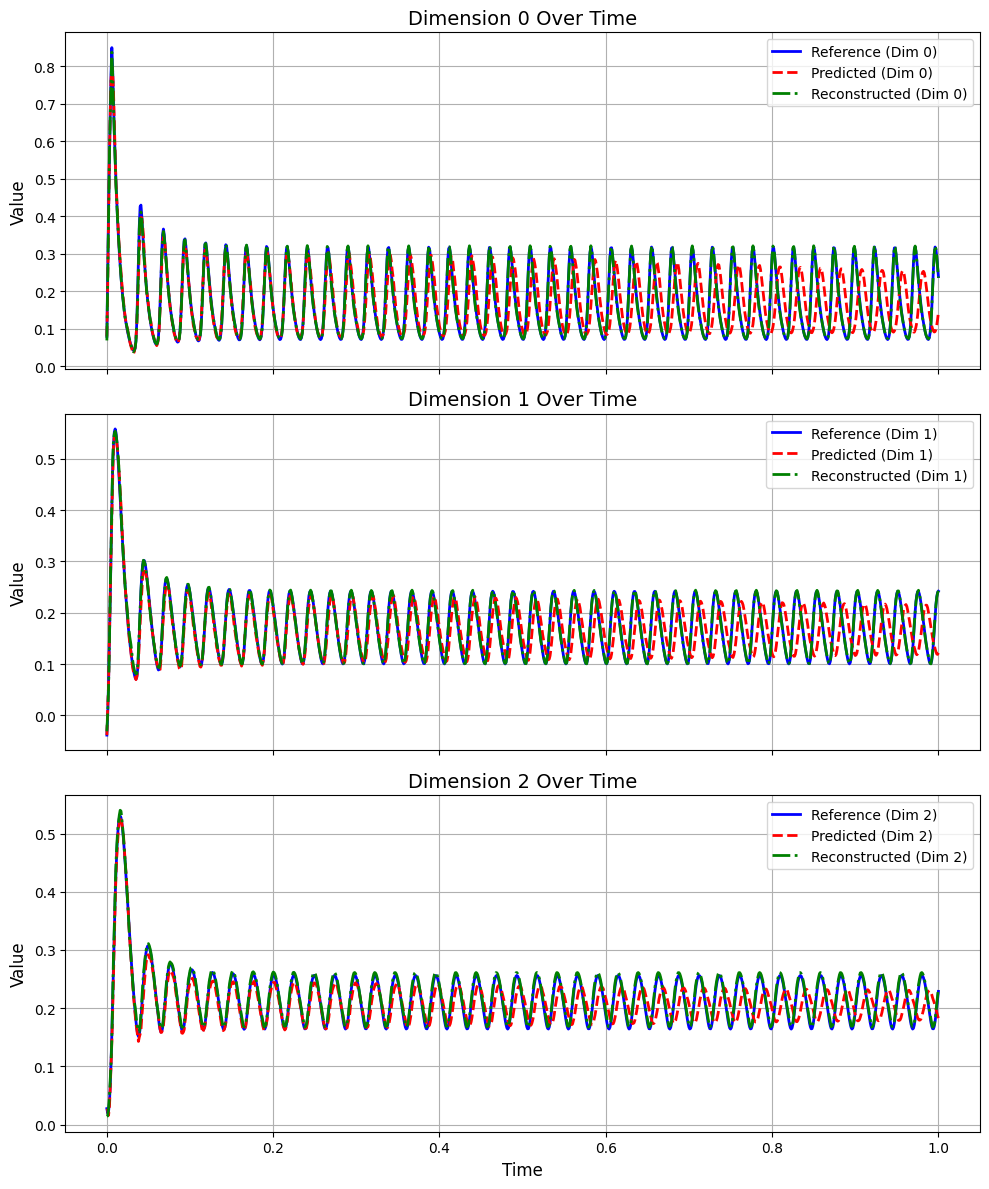

In [37]:
# traj as tensor
traj = torch.tensor(traj, dtype=torch.float32).to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj, latent_pred = trainer.predict_new(X0=traj[0], steps=len(traj)-1)

# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)


## Testing on Test Loader

In [18]:
# print length of test_loader
print(f" the length of the test_loader is {len(test_loader.dataset)}")

 the length of the test_loader is 600


In [19]:
print(test_loader.dataset[0][0].shape)

torch.Size([201, 3])


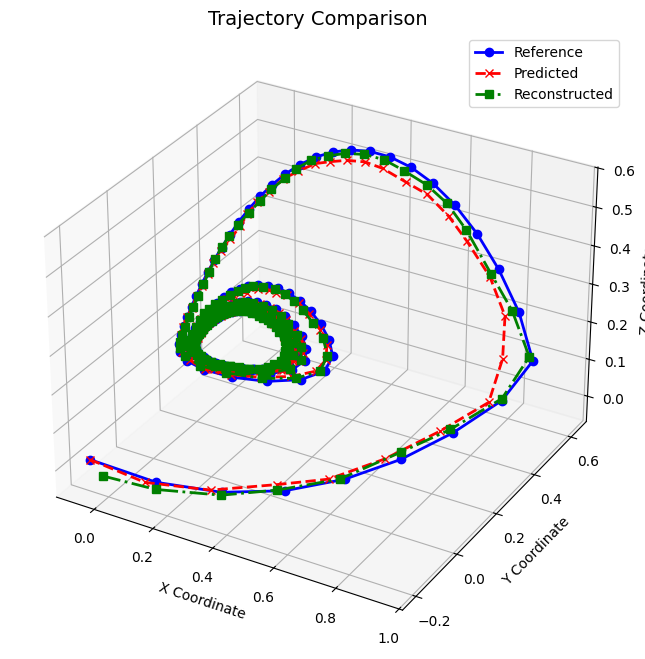

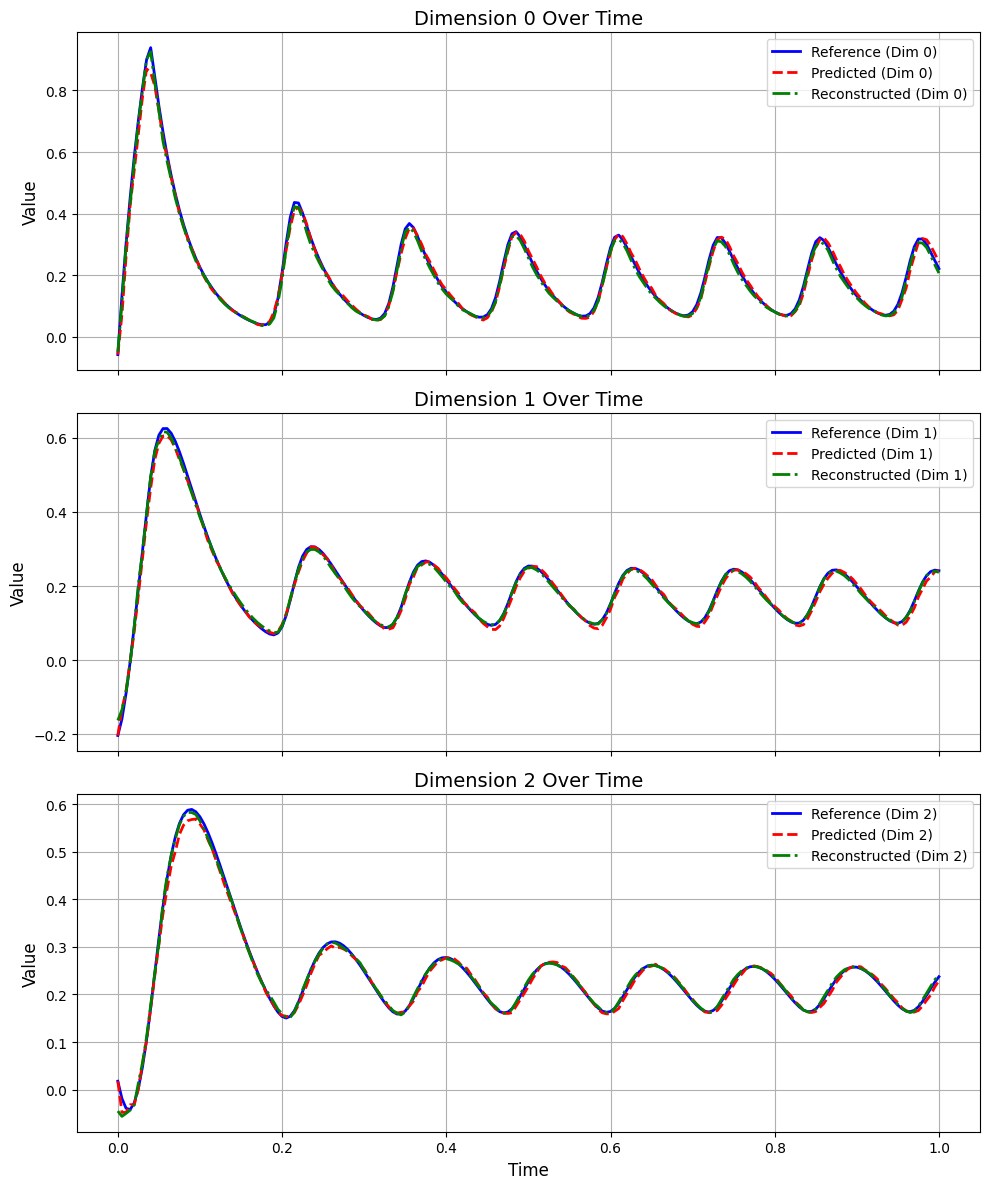

In [21]:
# Get a test sample
traj = train_loader.dataset[60][0].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj, latent_pred = trainer.predict_new(X0=traj[0], steps=len(traj)-1)

# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)

## Eigenvalues Visualization

Compute and visualize the eigenvalues of the Koopman operator on a unit circle.

Eigenvalues:
[ 1.0001057 +0.j          0.9970453 +0.07680552j  0.9970453 -0.07680552j
  0.9871526 -0.15999956j  0.9871526 +0.15999956j  0.97533774-0.22171801j
  0.97533774+0.22171801j  0.9713103 -0.23833446j  0.9713103 +0.23833446j
  0.96617806-0.25847355j  0.96617806+0.25847355j  0.9400836 -0.34099734j
  0.9400836 +0.34099734j  0.9164328 +0.40012318j  0.9164328 -0.40012318j
  0.8767828 +0.48105553j  0.8767828 -0.48105553j  0.83270264+0.55369866j
  0.83270264-0.55369866j  0.8069086 +0.59066653j  0.8069086 -0.59066653j
  0.76363623+0.6456434j   0.76363623-0.6456434j   0.7080153 -0.70617723j
  0.7080153 +0.70617723j  0.6803459 +0.7328775j   0.6803459 -0.7328775j
  0.6274339 -0.7786766j   0.6274339 +0.7786766j   0.61131823-0.7913915j
  0.61131823+0.7913915j   0.56126875+0.8276262j   0.56126875-0.8276262j
  0.5269358 -0.8499103j   0.5269358 +0.8499103j   0.4497937 -0.8931303j
  0.4497937 +0.8931303j   0.40399602+0.9147495j   0.40399602-0.9147495j
  0.34467885-0.9387134j   0.34467885+0.9387

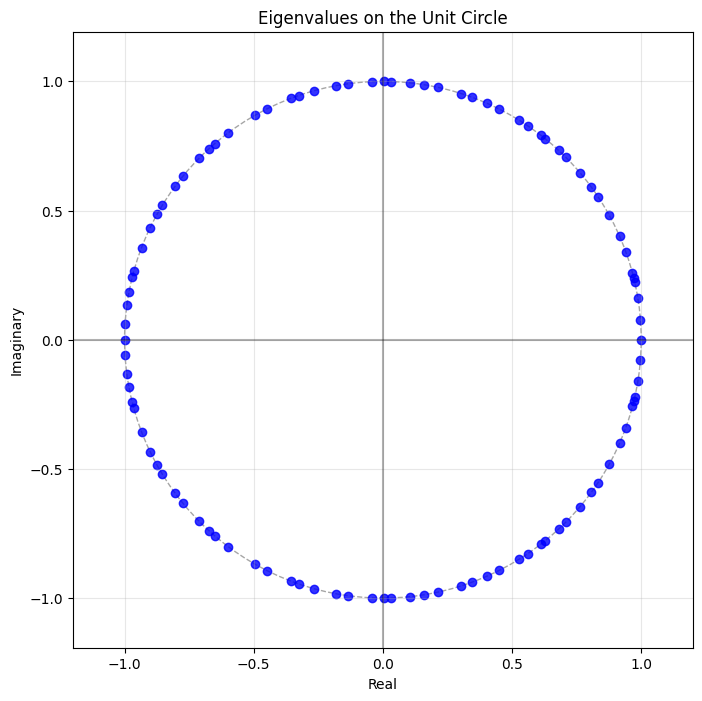

In [22]:
# Compute eigenvalues
eigenvalues, eigenvectors = torch.linalg.eig(model.knet.net.weight)
eigenvalues = eigenvalues.cpu().detach().numpy()
idx = np.argsort(eigenvalues.real)[::-1]
eigenvalues = eigenvalues[idx]

# Print eigenvalues
print('Eigenvalues:')
print(eigenvalues)

# Plot eigenvalues on unit circle
plot_eigenvalues_on_unit_circle(eigenvalues, folder_path)

print(f"Training and evaluation completed. Results saved in {folder_path}")

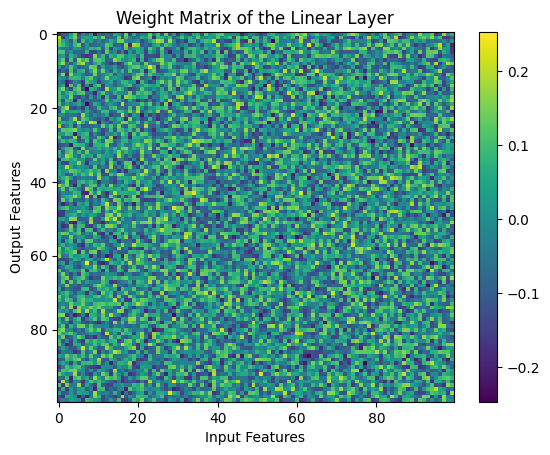

In [23]:
# print the knet weights
weights = model.knet.net.weight.cpu().detach().numpy() 
# Visualize the weight matrix using matplotlib
plt.imshow(weights, cmap='viridis', aspect='auto')
plt.colorbar()
plt.title("Weight Matrix of the Linear Layer")
plt.xlabel("Input Features")
plt.ylabel("Output Features")
plt.show()


In [24]:
# print the entire koopman operator in full 
print(f" the koopman operator is {model.knet.net.weight[0]}")

 the koopman operator is tensor([-1.8938e-01, -1.0406e-01, -8.5512e-02,  4.3712e-02,  1.4280e-01,
        -1.4764e-01, -1.7441e-02, -6.2565e-02,  3.2523e-02, -2.0874e-01,
        -5.4121e-02, -1.0126e-01, -7.4361e-02, -1.0856e-01,  6.2703e-02,
         2.0849e-02, -1.2878e-01,  1.5091e-01, -1.4927e-01,  6.9021e-02,
        -9.7095e-02, -1.8007e-02, -3.2278e-02,  1.4288e-01, -5.9094e-02,
         9.7659e-02, -1.2841e-01,  1.4382e-01, -1.1917e-01,  3.7599e-02,
        -1.6378e-01,  2.0059e-02, -8.5884e-02, -1.4257e-01,  5.9698e-02,
         7.3033e-02, -1.3272e-01,  1.2752e-01,  5.7485e-03,  5.4934e-02,
         1.1430e-01,  1.3575e-01, -4.7970e-03, -1.9808e-04,  1.9373e-02,
        -2.2466e-02, -1.9144e-01, -1.0648e-01, -1.5040e-02, -3.1012e-02,
        -9.8635e-02, -1.4910e-01, -1.0150e-01,  5.1819e-02,  7.9281e-02,
        -4.0161e-03, -3.6739e-02, -1.1994e-02,  5.6917e-02,  1.0252e-01,
         1.6022e-01,  1.1004e-01,  1.8330e-01, -4.8530e-02,  5.0200e-02,
         1.0458e-01,  1.60

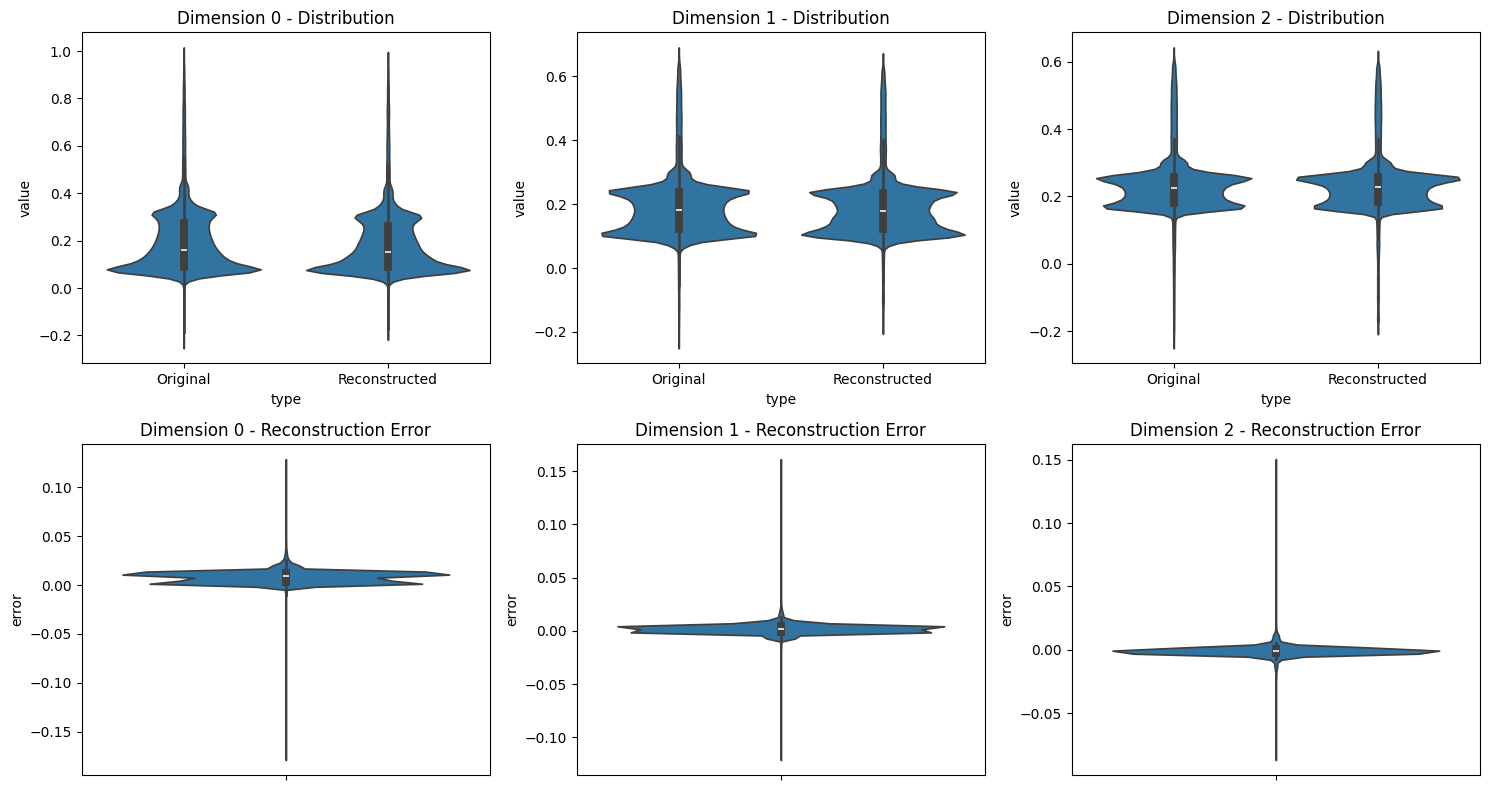

In [25]:
violin_plot(model, preprocessed_data["Xtest"], device, folder_path)